In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, LeaveOneGroupOut, RandomizedSearchCV
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import RegressorChain, MultiOutputRegressor

In [60]:
from matplotlib.font_manager import FontProperties
from matplotlib.font_manager import findfont

#sns.set_palette([  "#89A8F6","#0F42C6",'#C9CED5',  "#1C2029"])

sns.set_style('darkgrid',{
    "axes.facecolor": "#f0f0f0",
    "axes.linewidth": 1.5,
    'axes.grid': True,
    'axes.labelcolor': '#000',
    "font.size": 18,
    'axes.edgecolor': '#fff',
    'grid.color': '#9d9d9d',
    'text.color': '#000',
    'xtick.color': '#000'
})

In [61]:
df = pd.read_csv("bench_results/results_C.csv")

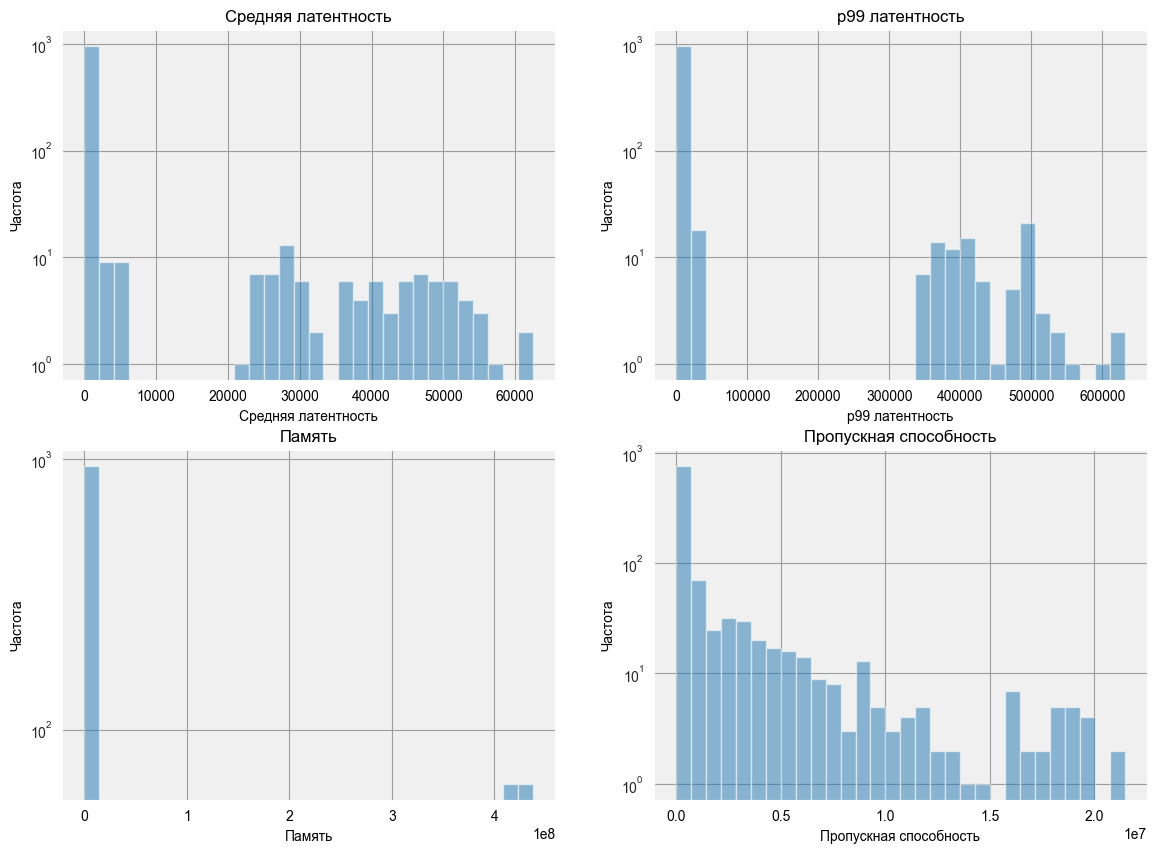

In [62]:
metrics = ['avg_latency_us', 'p99_latency_us', 'memory_usage_bytes', 'throughput_ops_sec']
titles = ['Средняя латентность', 'p99 латентность', 'Память', 'Пропускная способность']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, metric, title in zip(axes.flat, metrics, titles):
    ax.hist(df[metric], bins=30, alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel(title)
    ax.set_ylabel('Частота')
    ax.set_yscale('log')

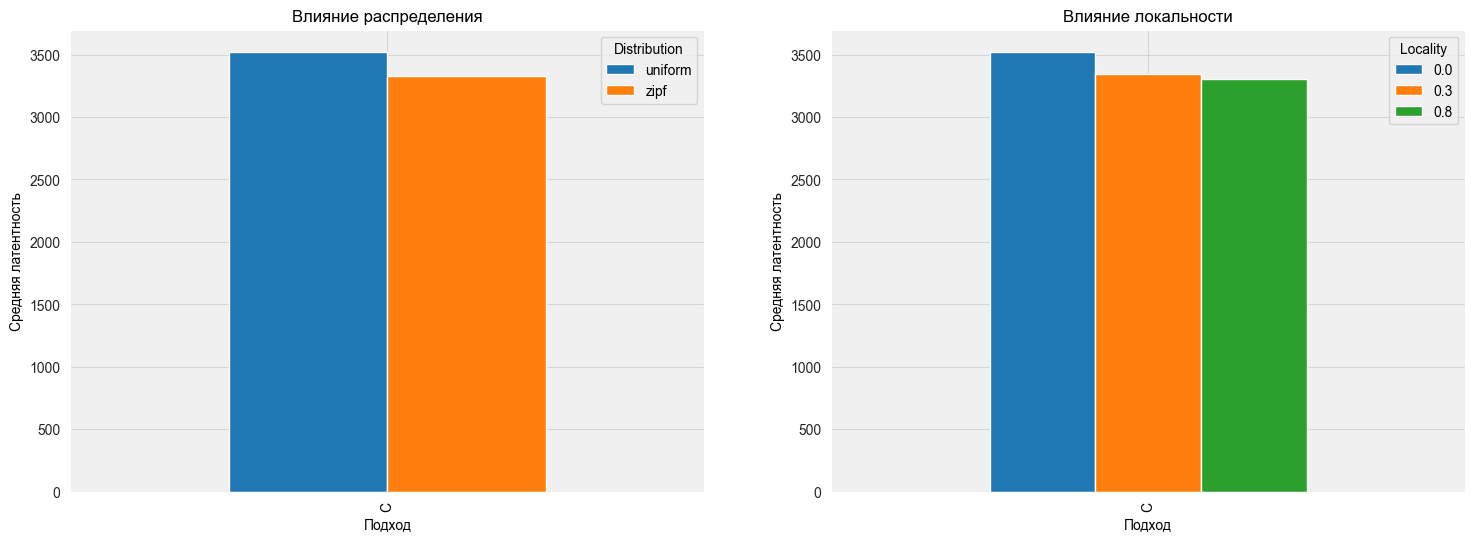

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

zipf_effect = df.groupby(['fs_type','distribution'])['avg_latency_us'].mean().unstack()
zipf_effect.plot(kind='bar', ax=axes[0])
axes[0].set_title('Влияние распределения')
axes[0].set_xlabel('Подход')
axes[0].set_ylabel('Средняя латентность')
axes[0].legend(title='Distribution')
axes[0].grid(True, alpha=0.3)

loc_effect = df.groupby(['fs_type','locality'])['avg_latency_us'].mean().unstack()
loc_effect.plot(kind='bar', ax=axes[1])
axes[1].set_title('Влияние локальности')
axes[1].set_xlabel('Подход')
axes[1].set_ylabel('Средняя латентность')
axes[1].legend(title='Locality')
axes[1].grid(True, alpha=0.3)

Text(0.5, 1.0, 'Корреляционная матрица')

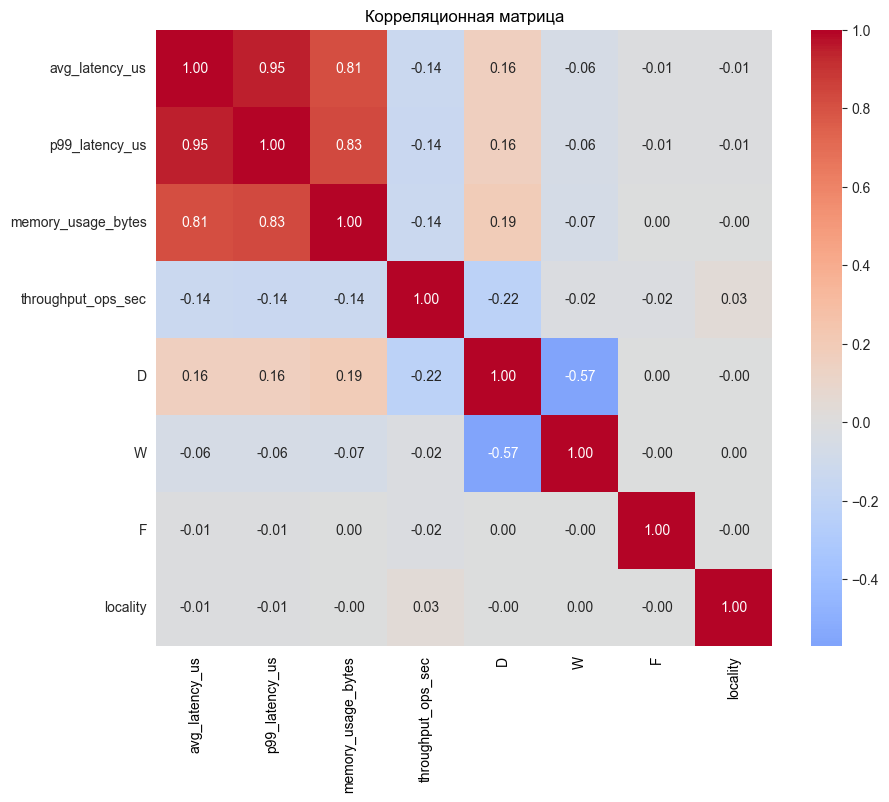

In [65]:
metric_cols = ['avg_latency_us','p99_latency_us','memory_usage_bytes','throughput_ops_sec','D','W','F','locality']
corr = df[metric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Корреляционная матрица')

Коэффициент корреляции Пирсона между avg_latency_us и p99_latency_us: 0.950


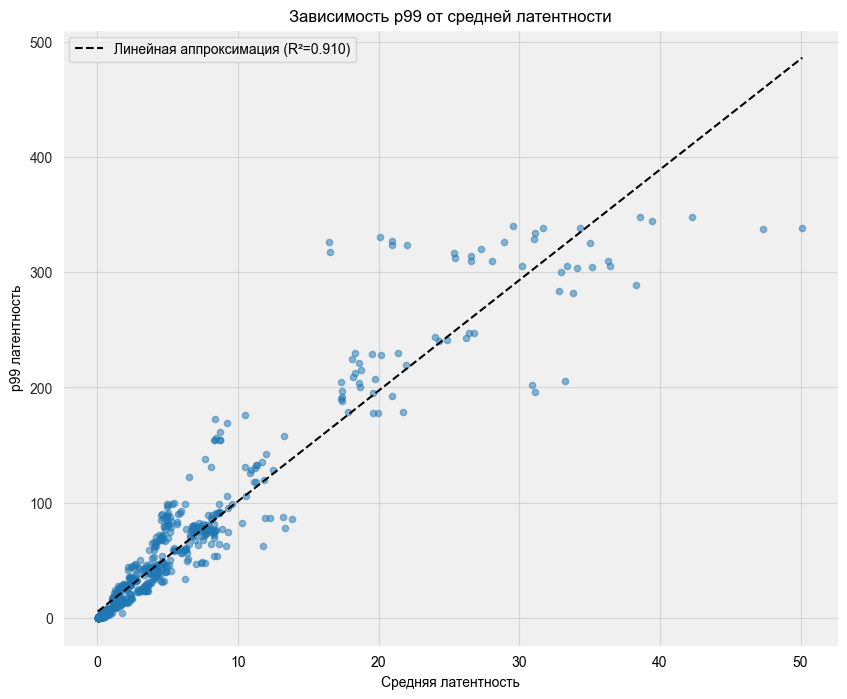

In [66]:
plt.figure(figsize=(10, 8))
sub = df[df['p99_latency_us']<350]
plt.scatter(sub['avg_latency_us'], sub['p99_latency_us'], alpha=0.5, s=20)

coef = np.polyfit(sub['avg_latency_us'], sub['p99_latency_us'], 1)
p = np.poly1d(coef)
x_line = np.linspace(sub['avg_latency_us'].min(), sub['avg_latency_us'].max(), 100)
r2_lin = np.corrcoef(sub['avg_latency_us'], sub['p99_latency_us'])[0,1]**2
plt.plot(x_line, p(x_line), 'k--', label=f'Линейная аппроксимация (R²={r2_lin:.3f})')

plt.xlabel('Средняя латентность')
plt.ylabel('p99 латентность')
plt.title('Зависимость p99 от средней латентности')
plt.legend()
plt.grid(True, alpha=0.3)

print(f"Коэффициент корреляции Пирсона между avg_latency_us и p99_latency_us: {pearsonr(df['avg_latency_us'], df['p99_latency_us'])[0]:.3f}")

In [67]:
def calculate_vif(X_df):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X_df.columns
    vif_data["VIF"] = [variance_inflation_factor(X_df.values, i) for i in range(X_df.shape[1])]
    return vif_data.sort_values(by="VIF", ascending=False)

# Линейная модель

In [89]:
df_ml = df.copy()

df_ml['estimated_nodes'] = df_ml['F'] * (df_ml['W']**(df_ml['D'] + 1) - 1) / (df_ml['W'] - 1)

df_ml['logD'] = np.log(df_ml['D'])
df_ml['logW'] = np.log(df_ml['W'])

df_ml.loc[df_ml['distribution'] == 'uniform', 'zipf_s'] = 0.0

df_ml['zipf_depth_interaction'] = df_ml['zipf_s'] * df_ml['logD']

df_ml['heavy_scan_ops'] = df_ml['p_ls'] + df_ml['p_find']
df_ml['mutation_ops'] = df_ml['p_write'] + df_ml['p_mv']

df_ml = pd.get_dummies(df_ml, columns=['distribution'], drop_first=True)
feature_cat = [c for c in df_ml.columns if c.startswith('distribution_')]

df_ml['log_estimated_nodes'] = np.log1p(df_ml['estimated_nodes'])
df_ml['nodes_x_read'] = df_ml['estimated_nodes'] * df_ml['p_read']
df_ml['nodes_x_mutation'] = df_ml['estimated_nodes'] * df_ml['mutation_ops']


feature_base = [
    'estimated_nodes',
    "logW",
    'locality',
    'zipf_s',
    'zipf_depth_interaction',
    'p_read',
    'p_ls',
    'p_find',
    'p_write',
    'p_mv',
    'log_estimated_nodes',
    'nodes_x_read',
    'nodes_x_mutation'
] 

features =feature_base

ordered_targets = ['memory_usage_bytes', 'avg_latency_us', 'p99_latency_us', 'throughput_ops_sec']

X = df_ml[features]
Y_ordered = df_ml[ordered_targets]

print("Математически обоснованные признаки:", features)
print("Размер матрицы признаков X:", X.shape)

Математически обоснованные признаки: ['estimated_nodes', 'logW', 'locality', 'zipf_s', 'zipf_depth_interaction', 'p_read', 'p_ls', 'p_find', 'p_write', 'p_mv', 'log_estimated_nodes', 'nodes_x_read', 'nodes_x_mutation']
Размер матрицы признаков X: (1071, 13)


Text(0.5, 1.0, 'Корреляционная матрица')

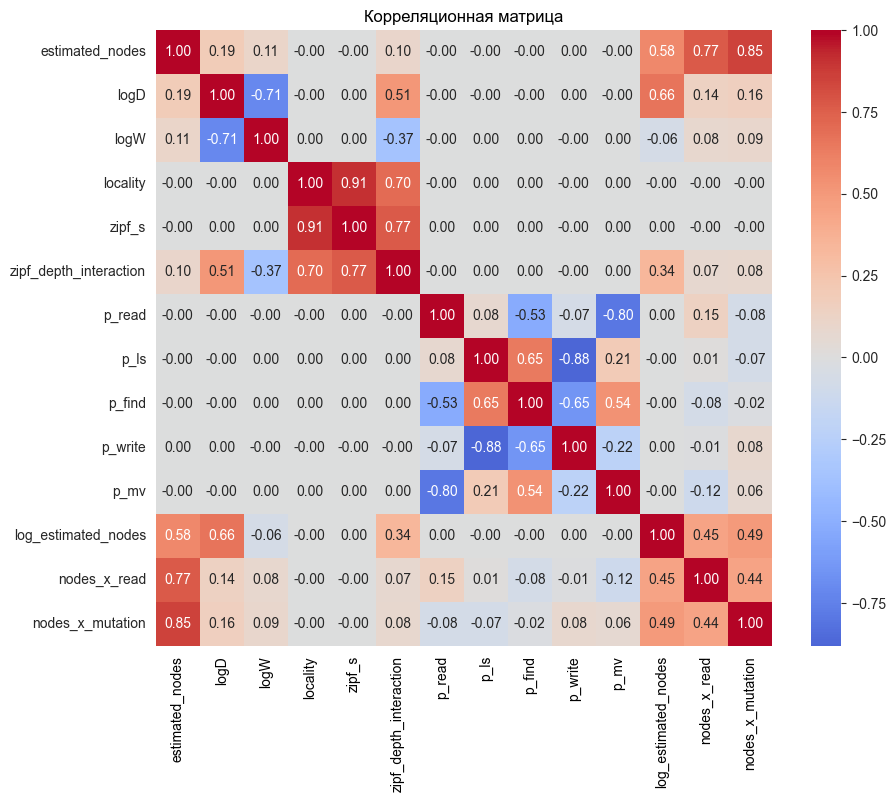

In [70]:
metric_cols = feature_base 
corr = df_ml[metric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Корреляционная матрица')

In [90]:
display(calculate_vif(X[feature_base]))

,Feature,VIF
0,estimated_nodes,13.843907
3,zipf_s,9.477552
7,p_find,7.334699
12,nodes_x_mutation,6.389794
4,zipf_depth_interaction,6.074974
2,locality,5.889827
6,p_ls,5.110262
8,p_write,4.813874
11,nodes_x_read,4.261420
5,p_read,3.564127


In [91]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y_ordered, test_size=0.2, random_state=42
)

scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

Y_train_scaled = scaler_Y.fit_transform(Y_train)

In [92]:
base_estimator = Ridge(random_state=42)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

orders_to_try = [
    [1,3, 0, 2],  # (memory_usage_bytes -> Avg Latency -> p99 -> throughput_ops_sec)
    [0, 3, 1, 2],  # (memory_usage_bytes -> throughput_ops_sec -> Avg Latency -> p99)
    [1, 2, 3, 0]   # (Avg Latency -> p99 -> throughput_ops_sec -> memory_usage_bytes)
]

param_grid = {'base_estimator__alpha': [0.3, 0.5, 0.8], 'order':orders_to_try} 

chain = RegressorChain(
    base_estimator=Ridge(random_state=42), 
    random_state=42
)

grid_search = GridSearchCV(
    estimator=chain, 
    param_grid=param_grid, 
    cv=kf, 
    scoring='r2', 
    n_jobs=-1
)

grid_search.fit(X_train_scaled, Y_train_scaled)
best_chain_model = grid_search.best_estimator_

print(grid_search.best_params_)

{'base_estimator__alpha': 0.8, 'order': [1, 3, 0, 2]}


In [93]:
Y_pred_scaled = best_chain_model.predict(X_test_scaled)
Y_pred_original = scaler_Y.inverse_transform(Y_pred_scaled)

y_preds = pd.DataFrame(Y_pred_original, columns=ordered_targets, index=Y_test.index)

metrics_list = []
for target in ordered_targets:
    y_true = Y_test[target]
    y_pr = y_preds[target]
    
    r2 = r2_score(y_true, y_pr)
    mae = mean_absolute_error(y_true, y_pr)
    rmse = np.sqrt(mean_squared_error(y_true, y_pr))
    mape = mean_absolute_percentage_error(y_true, y_pr)
    max_ape = np.max(np.abs(y_true - y_pr) / np.clip(np.abs(y_true), 1e-8, None))
    
    metrics_list.append({
        'Target': target, 
        'R²': round(r2, 4), 
        'MAE': round(mae, 2), 
        'RMSE': round(rmse, 2),
        'MAPE': f"{mape*100:.2f}%", 
        'Max Error %': f"{max_ape*100:.2f}%"
    })

display(pd.DataFrame(metrics_list))

,Target,R²,MAE,RMSE,MAPE,Max Error %
0,memory_usage_bytes,0.6371,63415567.56,83061781.16,328974.46%,9822196.94%
1,avg_latency_us,0.4862,5315.21,8458.82,1003302.32%,16949315.00%
2,p99_latency_us,0.4944,58883.64,87636.76,4849703.26%,120409207.04%
3,throughput_ops_sec,0.4791,1875479.43,3234889.66,586549.95%,16972616.55%


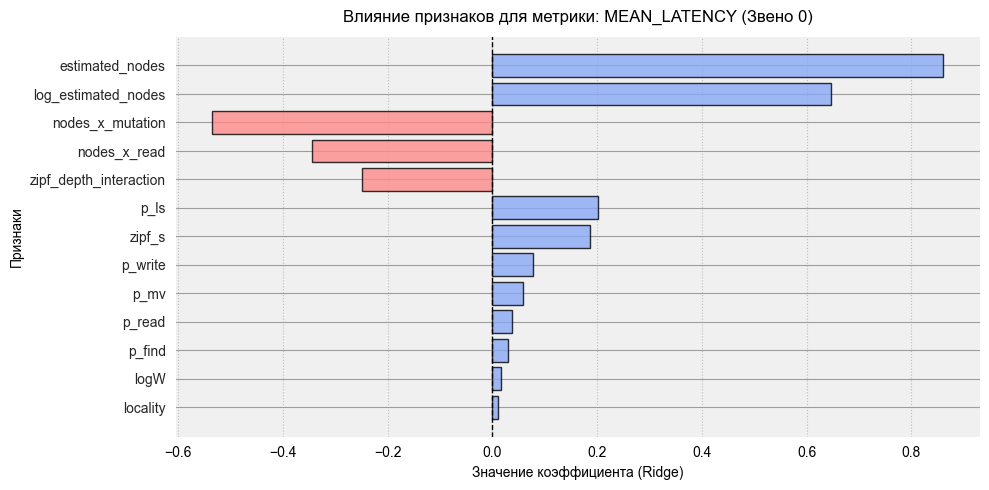

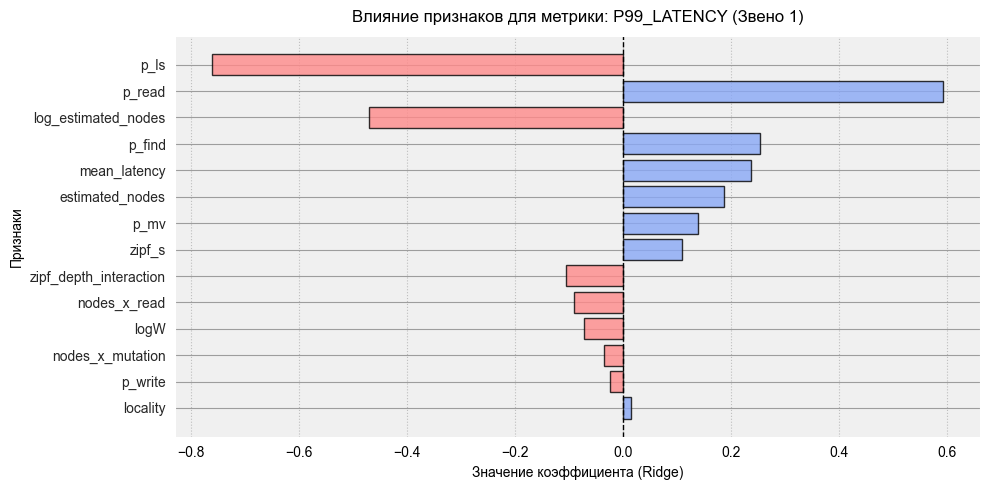

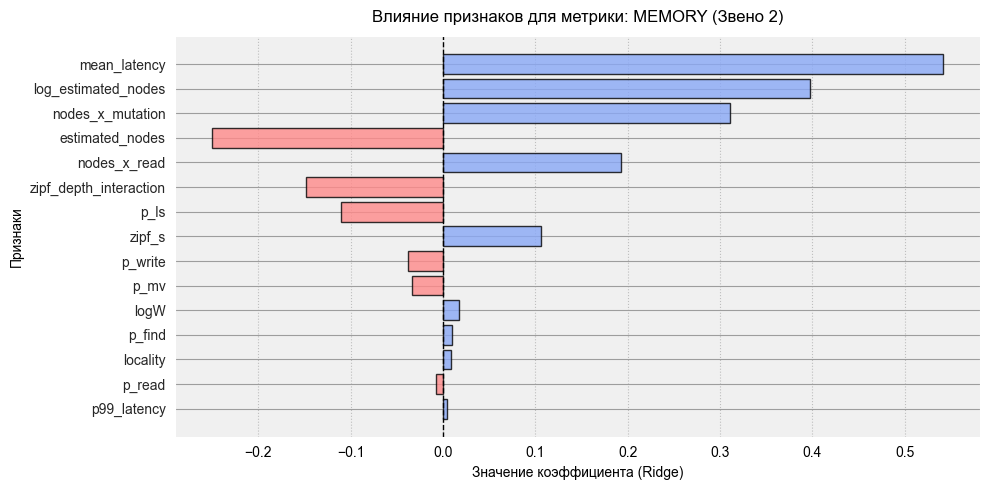

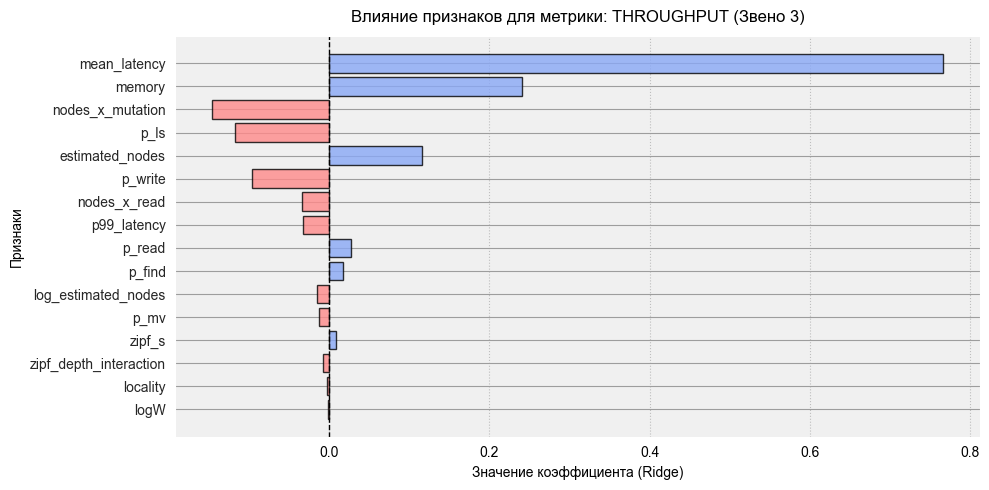

In [94]:

feature_names = list(X_train.columns)
target_names = ['mean_latency', 'p99_latency', 'memory', 'throughput']

for i, estimator in enumerate(best_chain_model.estimators_):
    current_features = feature_names + target_names[:i]
    coefficients = estimator.coef_

    importance_df = pd.DataFrame({
        'Feature': current_features,
        'Coefficient': coefficients,
        'Absolute': np.abs(coefficients)
    }).sort_values(by='Absolute', ascending=True)
    
    plt.figure(figsize=(10, 5))
    colors = ['#89A8F6' if c > 0 else '#FF8A8A' for c in importance_df['Coefficient']]
    
    plt.barh(importance_df['Feature'], importance_df['Coefficient'], color=colors, edgecolor='black', alpha=0.8)
    plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
    
    plt.title(f'Влияние признаков для метрики: {target_names[i].upper()} (Звено {i})', fontsize=12, pad=10)
    plt.xlabel('Значение коэффициента (Ridge)')
    plt.ylabel('Признаки')
    plt.grid(axis='x', linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()


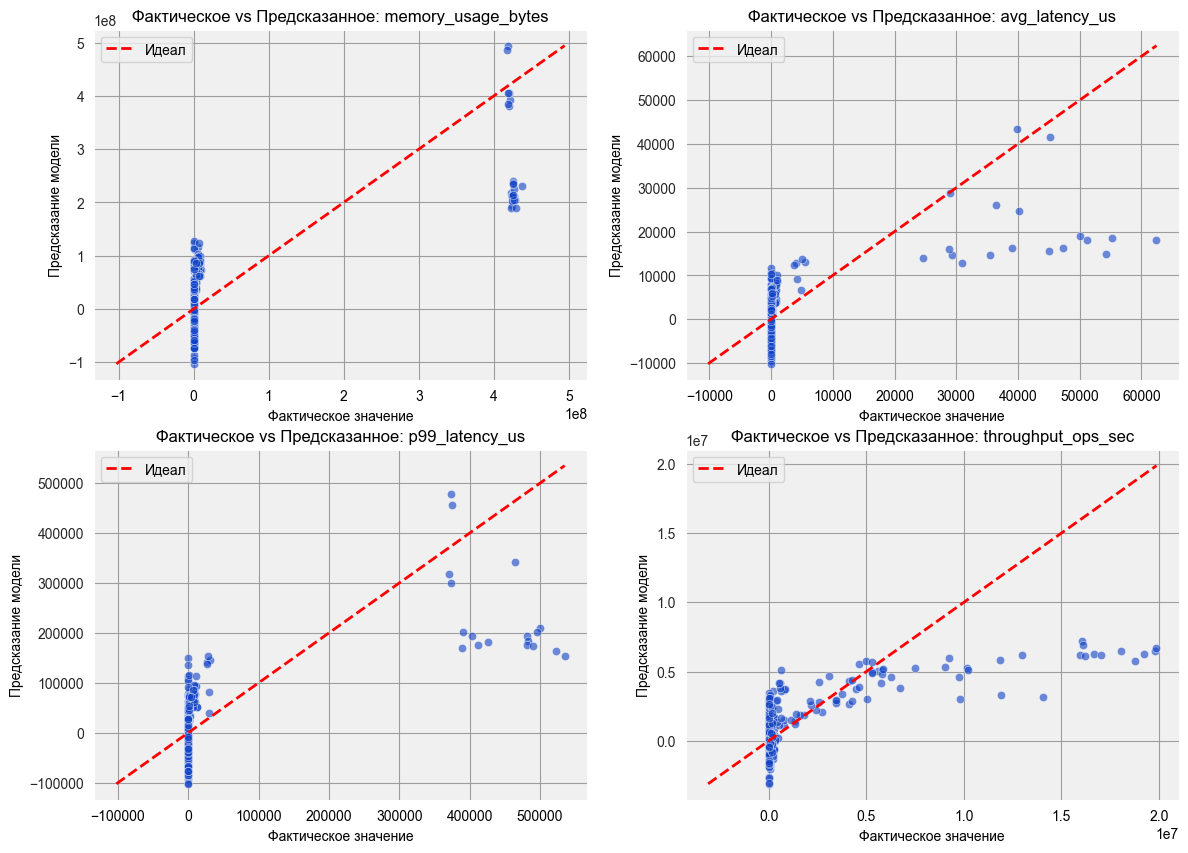

In [95]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, target in enumerate(ordered_targets):
    sns.scatterplot(x=Y_test[target], y=y_preds[target], ax=axes[i], alpha=0.6, color='#0F42C6')

    min_val = min(Y_test[target].min(), y_preds[target].min())
    max_val = max(Y_test[target].max(), y_preds[target].max())
    axes[i].plot([min_val, max_val], [min_val, max_val], '--r', lw=2, label='Идеал')
    
    axes[i].set_title(f"Фактическое vs Предсказанное: {target}")
    axes[i].set_xlabel("Фактическое значение")
    axes[i].set_ylabel("Предсказание модели")
    axes[i].legend()

Text(0.5, 1.0, 'Корреляция ошибок предсказания (Остатки)')

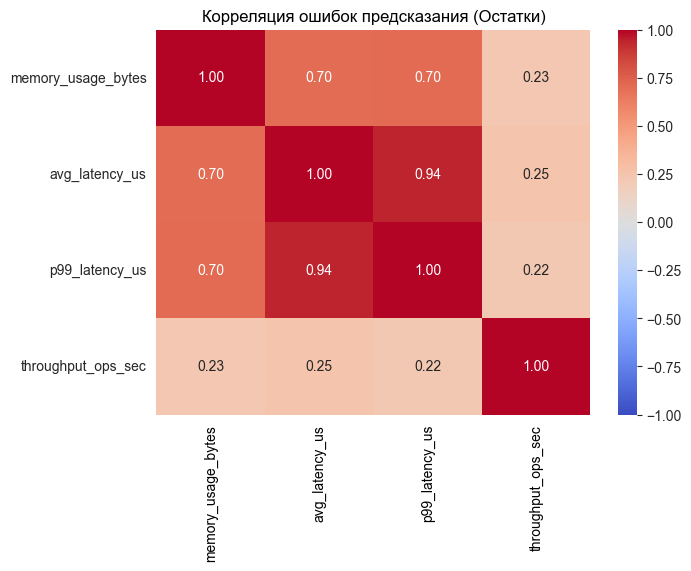

In [96]:
residuals = Y_test - y_preds

plt.figure(figsize=(7, 5))
sns.heatmap(residuals.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Корреляция ошибок предсказания (Остатки)")

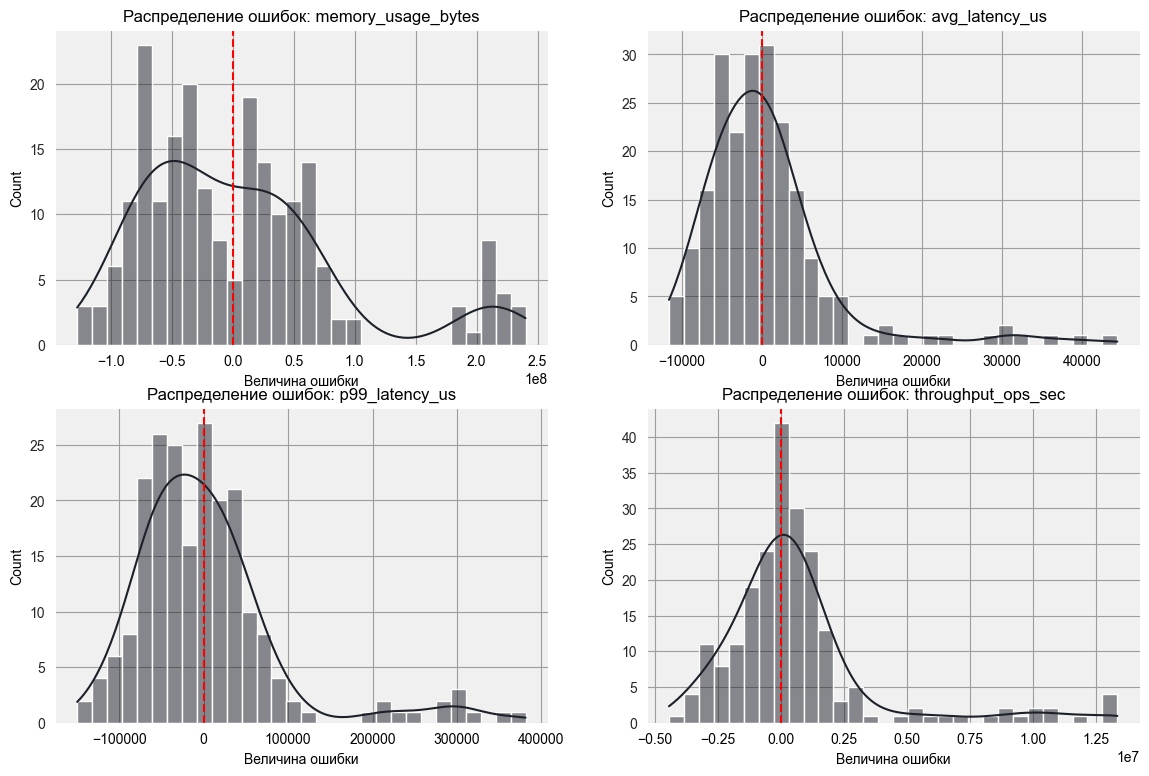

In [97]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

for i, target in enumerate(ordered_targets):
    sns.histplot(residuals[target], kde=True, ax=axes[i], color='#1C2029', bins=30)
    axes[i].axvline(x=0, color='r', linestyle='--')
    axes[i].set_title(f"Распределение ошибок: {target}")
    axes[i].set_xlabel("Величина ошибки")
    

# RANDOM FOREST

In [98]:
param_grid = {
    'estimator__n_estimators': [100, 200, 300],
    'estimator__max_depth': [None, 10, 20],
    'estimator__max_features': ['sqrt', 0.33, 'log2'],
    'estimator__min_samples_leaf': [1, 2, 5],
}

multi_rf = MultiOutputRegressor(
    RandomForestRegressor(random_state=42, oob_score=False)
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    multi_rf,
    param_grid,
    n_iter=20,
    cv=kf,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X_train_scaled, Y_train_scaled)
print("Лучшие параметры:", search.best_params_)
print("Лучший R² (CV):", round(search.best_score_, 4))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Лучшие параметры: {'estimator__n_estimators': 200, 'estimator__min_samples_leaf': 1, 'estimator__max_features': 0.33, 'estimator__max_depth': None}
Лучший R² (CV): 0.9871


In [99]:
best_params = {k.replace('estimator__', ''): v for k, v in search.best_params_.items()}
best_params['random_state'] = 42
best_params['oob_score'] = True

print("Параметры для цепочки:", best_params)

base_rf = RandomForestRegressor(**best_params)
chain_rf = RegressorChain(base_rf, order= grid_search.best_params_["order"])
chain_rf.fit(X_train_scaled, Y_train_scaled)

print(f"\nOOB R² первого звена цепочки (memory_usage_bytes): {chain_rf.estimators_[0].oob_score_:.4f}")

Параметры для цепочки: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 0.33, 'max_depth': None, 'random_state': 42, 'oob_score': True}

OOB R² первого звена цепочки (memory_usage_bytes): 0.9918


In [100]:
Y_pred_rf_scaled = chain_rf.predict(X_test_scaled)
Y_pred_rf = scaler_Y.inverse_transform(Y_pred_rf_scaled)

y_preds_rf = pd.DataFrame(Y_pred_rf, columns=ordered_targets, index=Y_test.index)

metrics_rf = []
for target in ordered_targets:
    y_true = Y_test[target]
    y_pr = y_preds_rf[target]
    metrics_rf.append({
        'Target': target,
        'R²': round(r2_score(y_true, y_pr), 4),
        'MAE': round(mean_absolute_error(y_true, y_pr), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pr)), 2),
        'MAPE': f"{mean_absolute_percentage_error(y_true, y_pr)*100:.2f}%",
    })

display(pd.DataFrame(metrics_rf))

,Target,R²,MAE,RMSE,MAPE
0,memory_usage_bytes,0.9995,748531.77,2957269.01,80.78%
1,avg_latency_us,0.9865,330.36,1369.17,1943.37%
2,p99_latency_us,0.9592,4659.40,24902.47,1501.70%
3,throughput_ops_sec,0.9320,457058.95,1168873.02,190.32%


In [101]:
import joblib

joblib.dump(chain_rf, 'model/C/random_forest_pipeline.joblib')

joblib.dump(scaler_X, 'model/C/scaler_X.joblib')
joblib.dump(scaler_Y, 'model/C/scaler_Y.joblib')

['model/C/scaler_Y.joblib']

Text(0.5, 1.02, 'Random Forest: Фактическое vs Предсказанное')

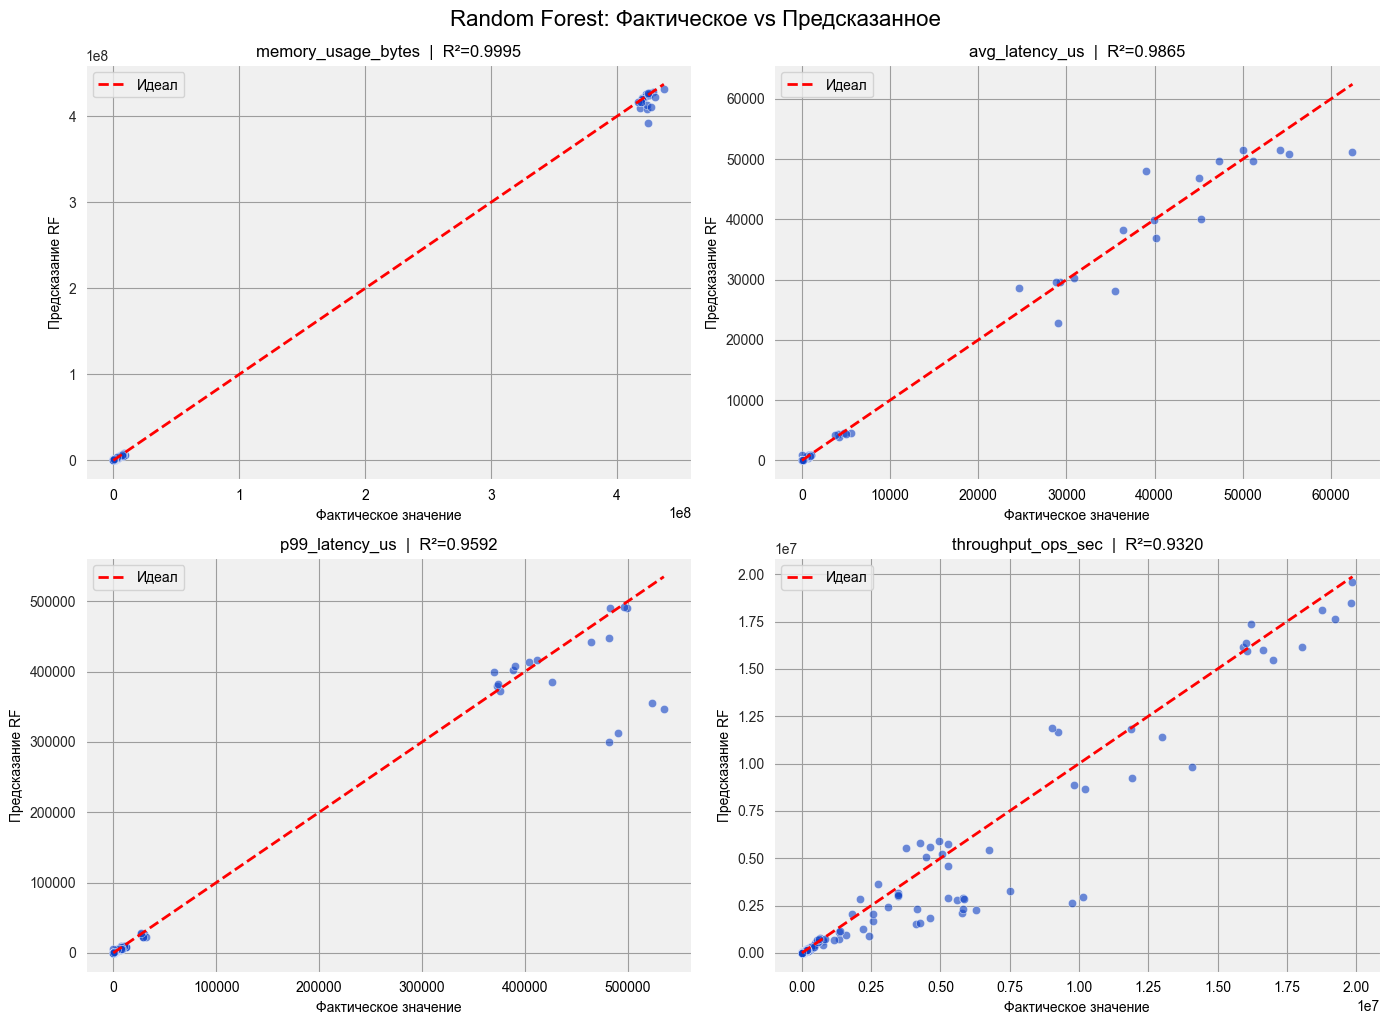

In [102]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, target in enumerate(ordered_targets):
    sns.scatterplot(x=Y_test[target], y=y_preds_rf[target], ax=axes[i], alpha=0.6, color='#0F42C6')

    min_val = min(Y_test[target].min(), y_preds_rf[target].min())
    max_val = max(Y_test[target].max(), y_preds_rf[target].max())
    axes[i].plot([min_val, max_val], [min_val, max_val], '--r', lw=2, label='Идеал')

    r2 = r2_score(Y_test[target], y_preds_rf[target])
    axes[i].set_title(f"{target}  |  R²={r2:.4f}")
    axes[i].set_xlabel("Фактическое значение")
    axes[i].set_ylabel("Предсказание RF")
    axes[i].legend()

plt.tight_layout()
plt.suptitle("Random Forest: Фактическое vs Предсказанное", fontsize=16, y=1.02)

In [103]:
residuals_rf = Y_test.values - Y_pred_rf
resid_df = pd.DataFrame(residuals_rf, columns=ordered_targets, index=Y_test.index)

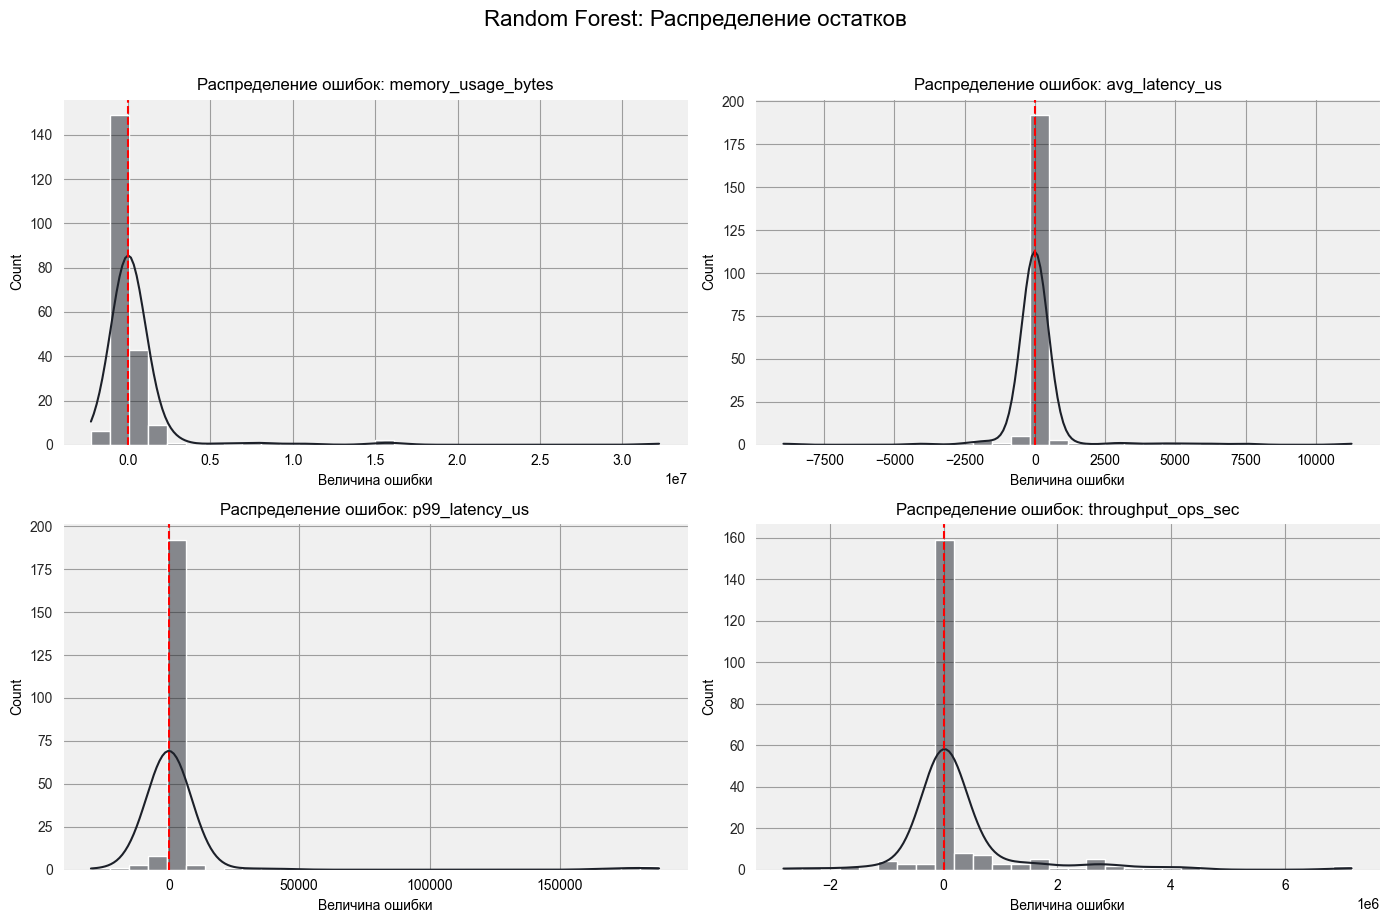

In [104]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

for i, target in enumerate(ordered_targets):
    sns.histplot(resid_df[target], kde=True, ax=axes[i], color='#1C2029', bins=30)
    axes[i].axvline(x=0, color='r', linestyle='--')
    axes[i].set_title(f"Распределение ошибок: {target}")
    axes[i].set_xlabel("Величина ошибки")

plt.suptitle("Random Forest: Распределение остатков", fontsize=16, y=1.02)
plt.tight_layout()

Text(0.5, 1.0, 'Корреляция ошибок предсказания RF (остатки)')

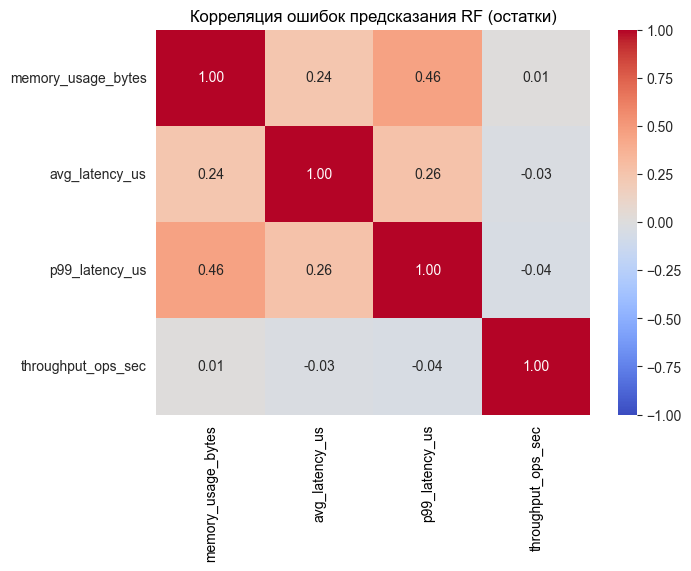

In [105]:
plt.figure(figsize=(7, 5))
sns.heatmap(resid_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Корреляция ошибок предсказания RF (остатки)")

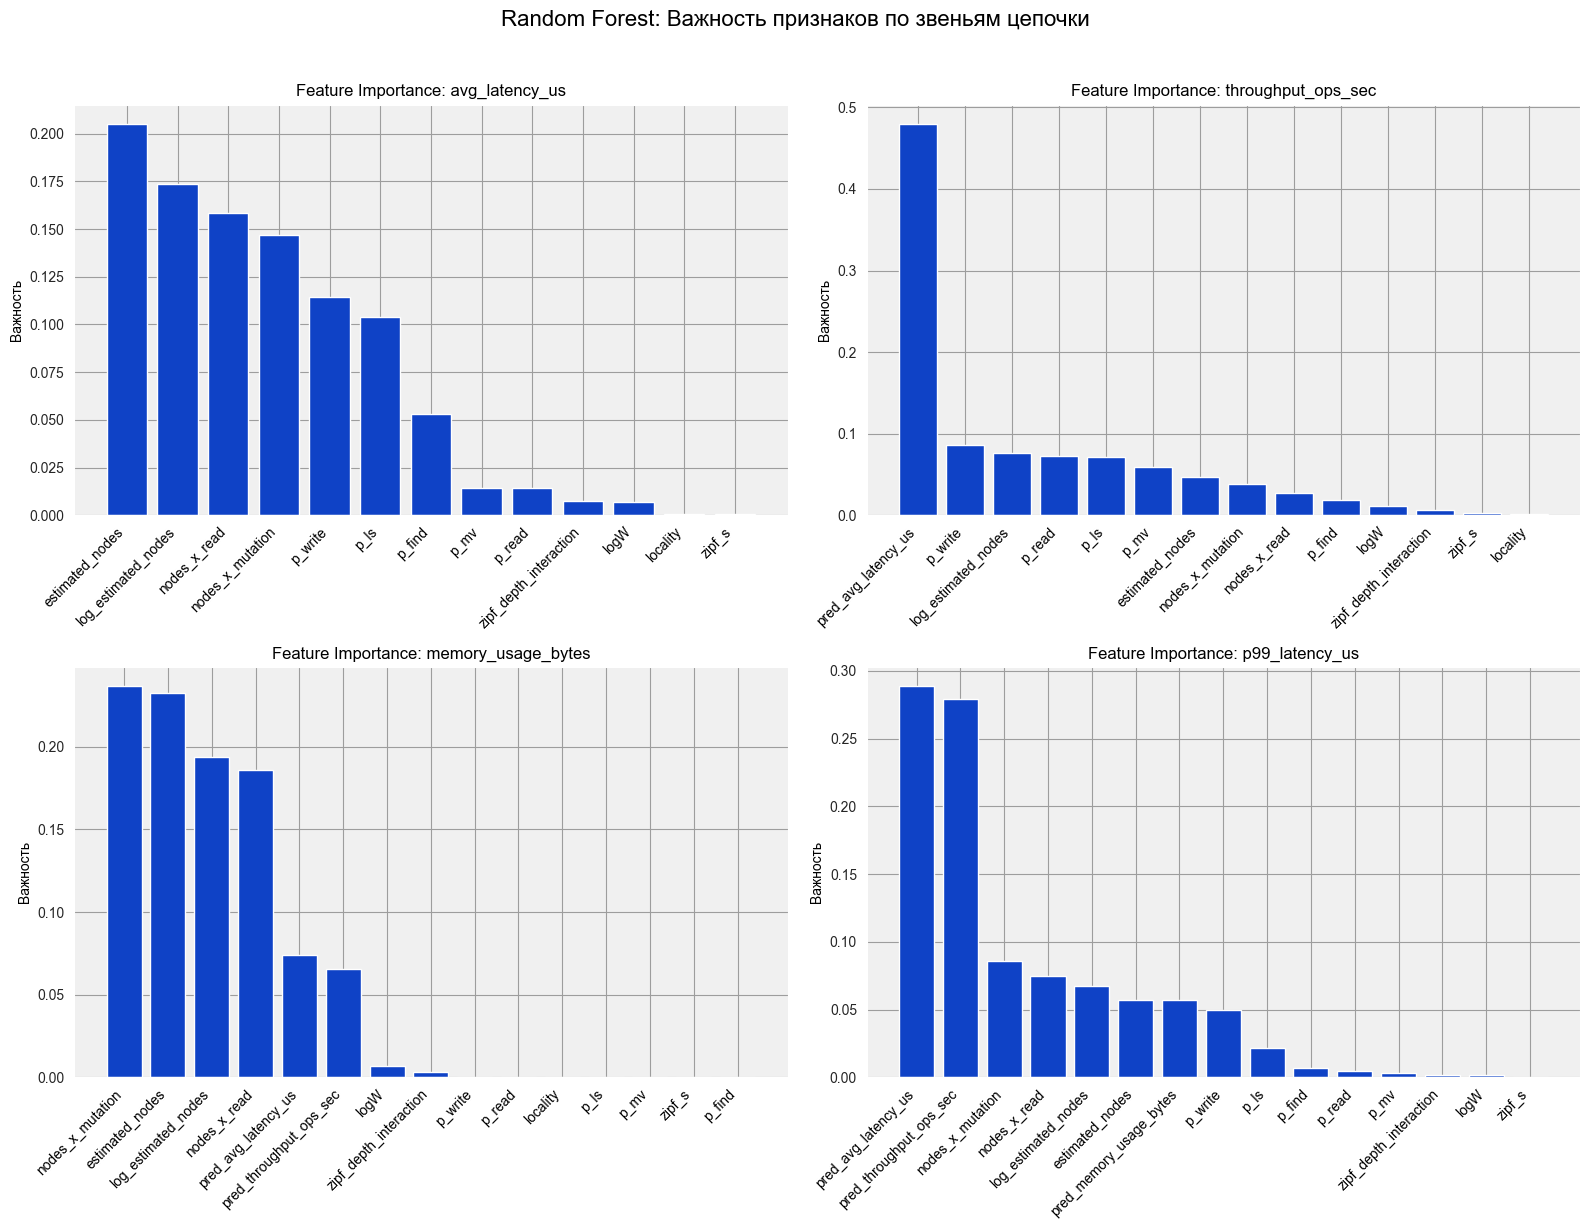

In [106]:
real_feature_names = list(X_train.columns)

order = chain_rf.order_
ordered_target_names = [ordered_targets[idx] for idx in order]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, (estimator, target) in enumerate(zip(chain_rf.estimators_, ordered_target_names)):
    n_original = len(real_feature_names)
    n_extra = estimator.n_features_in_ - n_original
    
    extra_names = [f"pred_{ordered_target_names[j]}" for j in range(n_extra)]
    all_names = real_feature_names + extra_names

    importances = estimator.feature_importances_
    sorted_idx = np.argsort(importances)[::-1][:15] 

    axes[i].bar(range(len(sorted_idx)), importances[sorted_idx], color='#0F42C6')
    axes[i].set_xticks(range(len(sorted_idx)))
    axes[i].set_xticklabels([all_names[j] for j in sorted_idx], rotation=45, ha='right', fontsize=10)
    axes[i].set_title(f"Feature Importance: {target}")
    axes[i].set_ylabel("Важность")

plt.suptitle("Random Forest: Важность признаков по звеньям цепочки", fontsize=16, y=1.02)
plt.tight_layout()